# [HW4] 3D-реконструкция объектов методом Gaussian Splatting

Frolova AI, M25-RO-01

`https://github.com/kicchhi/Advanced-Robotics`

## 🎯 Цель работы

Реализовать полный конвейер создания фотореалистичного «цифрового двойника» реального объекта с использованием метода **Gaussian Splatting (3DGS)** и сравнить результаты классической реконструкции **Structure from Motion (COLMAP)** с нейросетевым рендерингом.

**Основные задачи:**
- Подготовка данных (съемка объекта, конвертация форматов)
- Выполнение SfM реконструкции средствами COLMAP
- Обучение модели Gaussian Splatting с разными параметрами
- Сравнение качества реконструкции
- Визуализация и анализ результатов

In [ ]:
!apt-get install -y colmap
!git clone https://github.com/graphdeco-inria/gaussian-splatting --recursive
!pip install plyfile opencv-python tqdm

%cd /content/gaussian-splatting
!pip install submodules/diff-gaussian-rasterization
!pip install submodules/simple-knn
%cd /content

# Данные

Было снято видео, из которого нарезаны картинки при помощи скрипта. Фото загружены на диск.

📸 ЗАГРУЗКА ФОТОГРАФИЙ ИЗ GOOGLE DRIVE
✅ Папка найдена: /content/drive/MyDrive/3DGS_Project/images
📸 Найдено изображений: 49

📁 Копирование изображений...
   Скопировано 20 из 49
   Скопировано 40 из 49
✅ Скопировано 49 изображений

📊 ПРОВЕРКА КАЧЕСТВА ФОТОГРАФИЙ
✅ Всего фотографий: 49

🔍 Анализ качества фотографий...
  frame_0000.jpg: ✅ резкость=204.4
  frame_0001.jpg: ⚠️ резкость=53.1
  frame_0002.jpg: ⚠️ резкость=54.6
  frame_0003.jpg: ⚠️ резкость=57.0
  frame_0004.jpg: ⚠️ резкость=63.9
  frame_0005.jpg: ✅ резкость=96.3
  frame_0006.jpg: ✅ резкость=92.0
  frame_0007.jpg: ⚠️ резкость=75.5
  frame_0008.jpg: ✅ резкость=83.1
  frame_0009.jpg: ⚠️ резкость=56.0
  frame_0010.jpg: ✅ резкость=89.6
  frame_0011.jpg: ✅ резкость=115.0
  frame_0012.jpg: ✅ резкость=89.8
  frame_0013.jpg: ✅ резкость=120.2
  frame_0014.jpg: ✅ резкость=81.7
  frame_0015.jpg: ✅ резкость=99.3
  frame_0016.jpg: ⚠️ резкость=78.3
  frame_0017.jpg: ✅ резкость=102.0
  frame_0018.jpg: ✅ резкость=107.1
  frame_0019.jpg: ✅ рез

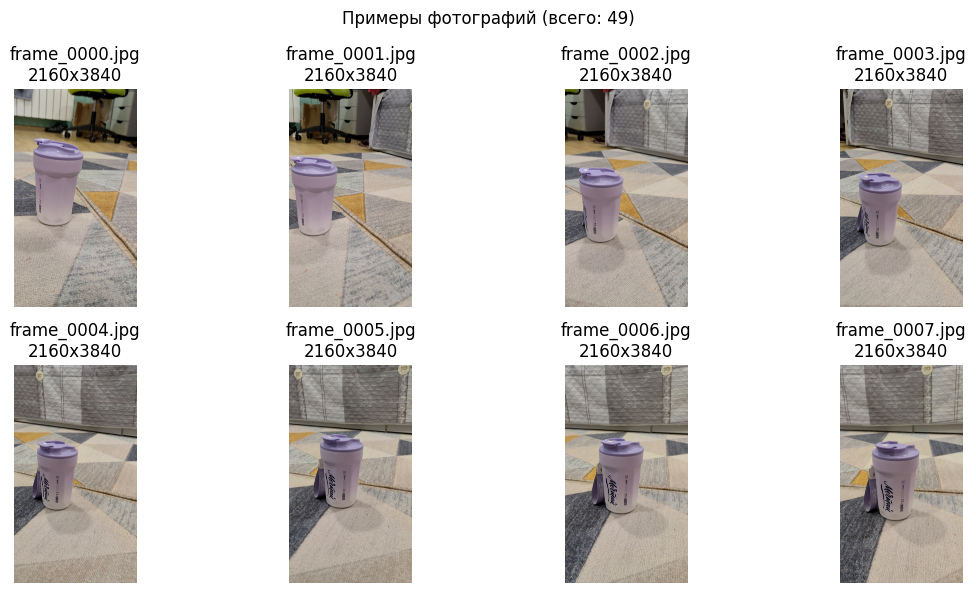


💾 СОХРАНЕНИЕ ИНФОРМАЦИИ О ДАТАСЕТЕ
✅ Информация сохранена: /content/data/dataset_info.txt

✅ ПОДГОТОВКА ЗАВЕРШЕНА!

📁 Расположение файлов:
   Изображения: /content/data/images
   Всего файлов: 49

📌 Следующие шаги:
  1. Перейдите к ячейке с COLMAP
  2. Запустите извлечение признаков
  3. Выполните сопоставление признаков
  4. Постройте модель

💡 Совет: Если фотографий 50+, COLMAP будет работать ~5-10 минут


In [ ]:
import os
import shutil
import glob
import cv2
import matplotlib.pyplot as plt
import numpy as np
import subprocess
from plyfile import PlyData

# Путь к папке с изображениями
source_folder = "/content/drive/MyDrive/3DGS_Project/images"
data_dir = "/content/data"

# Создаем папку для изображений
os.makedirs(f"{data_dir}/images", exist_ok=True)

print("=" * 70)
print("📸 ЗАГРУЗКА ФОТОГРАФИЙ ИЗ GOOGLE DRIVE")
print("=" * 70)

print(f"✅ Папка найдена: {source_folder}")

# Считаем количество изображений
image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
all_images = []

for ext in image_extensions:
    all_images.extend(glob.glob(os.path.join(source_folder, ext)))

print(f"📸 Найдено изображений: {len(all_images)}")

if len(all_images) == 0:
    print("⚠️ ВНИМАНИЕ: В папке нет изображений!")
    print("   Поддерживаемые форматы: .jpg, .jpeg, .png")
else:
    # Копируем изображения
    print("\n📁 Копирование изображений...")
    copied_count = 0

    for img_path in all_images:
        filename = os.path.basename(img_path)
        dest_path = f"{data_dir}/images/{filename}"

        # Копируем только если файла нет или он отличается
        if not os.path.exists(dest_path):
            shutil.copy2(img_path, dest_path)
            copied_count += 1
            if copied_count % 20 == 0:
                print(f"   Скопировано {copied_count} из {len(all_images)}")

    print(f"✅ Скопировано {copied_count} изображений")


print("\n" + "=" * 70)
print("📊 ПРОВЕРКА КАЧЕСТВА ФОТОГРАФИЙ")
print("=" * 70)

# Получаем список всех изображений
images = sorted([f for f in os.listdir(f"{data_dir}/images")
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

print(f"✅ Всего фотографий: {len(images)}")

if len(images) < 30:
    print("⚠️ ВНИМАНИЕ: Мало фотографий (<30)")
    print("   Рекомендуется 50-100 для хорошего результата")
    print("   Для COLMAP нужно минимум 20 фотографий")

# Проверяем резкость и размеры
print("\n🔍 Анализ качества фотографий...")

sharpness_values = []
image_sizes = []

for img_name in images[:20]:  # Проверяем первые 20
    img_path = f"{data_dir}/images/{img_name}"
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is not None:
        # Резкость (дисперсия Лапласиана)
        var = cv2.Laplacian(img, cv2.CV_64F).var()
        sharpness_values.append(var)
        image_sizes.append(img.shape)

        status = "✅" if var > 80 else "⚠️"
        print(f"  {img_name[:30]}: {status} резкость={var:.1f}")

if sharpness_values:
    avg_sharp = np.mean(sharpness_values)
    print(f"\n📊 Средняя резкость: {avg_sharp:.1f}")

    if avg_sharp < 80:
        print("⚠️ Кадры размытые, рекомендуется использовать более четкие фото")
    elif avg_sharp > 150:
        print("✅ Отличная резкость!")

# Показываем примеры фотографий
print("\n🖼️ Примеры фотографий:")
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()

for i, img_name in enumerate(images[:8]):
    img = cv2.imread(f"{data_dir}/images/{img_name}")
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)
        axes[i].set_title(f"{img_name[:20]}\n{img.shape[1]}x{img.shape[0]}")
    axes[i].axis('off')

plt.suptitle(f"Примеры фотографий (всего: {len(images)})", fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("💾 СОХРАНЕНИЕ ИНФОРМАЦИИ О ДАТАСЕТЕ")
print("=" * 70)

# Сохраняем информацию о датасете
info_file = f"{data_dir}/dataset_info.txt"
with open(info_file, 'w') as f:
    f.write("Dataset Information\n")
    f.write("=" * 50 + "\n")
    f.write(f"Source: {source_folder}\n")
    f.write(f"Total images: {len(images)}\n")
    if sharpness_values:
        f.write(f"Average sharpness: {avg_sharp:.1f}\n")
    f.write(f"Image sizes: {list(set(image_sizes)) if image_sizes else 'N/A'}\n")

print(f"✅ Информация сохранена: {info_file}")

print("\n" + "=" * 70)
print("✅ ПОДГОТОВКА ЗАВЕРШЕНА!")
print("=" * 70)

print(f"\n📁 Расположение файлов:")
print(f"   Изображения: {data_dir}/images")
print(f"   Всего файлов: {len(images)}")

print("\n📌 Следующие шаги:")
print("  1. Перейдите к ячейке с COLMAP")
print("  2. Запустите извлечение признаков")
print("  3. Выполните сопоставление признаков")
print("  4. Постройте модель")
print("\n💡 Совет: Если фотографий 50+, COLMAP будет работать ~5-10 минут")

# COLMAP

1. **Извлечение признаков** — поиск характерных точек на изображениях
2. **Сопоставление признаков** — поиск соответствий между изображениями
3. **Оценка геометрии** — вычисление относительного положения камер
4. **Оптимизация** — минимизация ошибки репроекции

In [18]:
print("\n1/3: ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ")

result = subprocess.run(
    f"colmap feature_extractor "
    f"--database_path {data_dir}/colmap.db "
    f"--image_path {data_dir}/images "
    f"--ImageReader.camera_model PINHOLE "
    f"--SiftExtraction.use_gpu 1 "
    f"--SiftExtraction.max_num_features 4000",
    shell=True,
    capture_output=False  # Показываем вывод в реальном времени
)

print("\n✅ Извлечение признаков завершено")


1/3: ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ

✅ Извлечение признаков завершено


In [19]:
print("\n2/3: СОПОСТАВЛЕНИЕ ПРИЗНАКОВ")

result = subprocess.run(
    f"colmap sequential_matcher "
    f"--database_path {data_dir}/colmap.db "
    f"--SiftMatching.use_gpu 1",
    shell=True,
    capture_output=False
)

print("\n✅ Сопоставление завершено")


2/3: СОПОСТАВЛЕНИЕ ПРИЗНАКОВ

✅ Сопоставление завершено


In [20]:
print("\n3/3: ПОСТРОЕНИЕ МОДЕЛИ")

result = subprocess.run(
    f"colmap mapper "
    f"--database_path {data_dir}/colmap.db "
    f"--image_path {data_dir}/images "
    f"--output_path {data_dir}/sparse",
    shell=True,
    capture_output=False
)

print("\n✅ Построение модели завершено")


3/3: ПОСТРОЕНИЕ МОДЕЛИ

✅ Построение модели завершено


In [21]:
print("ПРОВЕРКА РЕЗУЛЬТАТА")

if os.path.exists(f"{data_dir}/sparse/0"):
    print("✅ МОДЕЛЬ СОЗДАНА!")

    # Считаем точки
    points_file = f"{data_dir}/sparse/0/points3D.txt"
    if os.path.exists(points_file):
        with open(points_file) as f:
            points = sum(1 for line in f if line.strip() and not line.startswith("#"))
        print(f"📍 Построено точек: {points}")

    # Копируем для 3DGS
    os.makedirs(f"{data_dir}/images/sparse/0", exist_ok=True)
    !cp -r {data_dir}/sparse/0/* {data_dir}/images/sparse/0/

else:
    print("❌ МОДЕЛЬ НЕ СОЗДАНА")
    print("\n🔍 Диагностика:")

    # Проверяем базу данных
    result = subprocess.run(
        f"colmap database_reader --database_path {data_dir}/colmap.db --show_statistics",
        shell=True,
        capture_output=True,
        text=True
    )
    print(result.stdout)

    print("\n💡 Возможные причины:")
    print("  - Мало фотографий (нужно 50-100)")
    print("  - Малое перекрытие между кадрами (<70%)")
    print("  - Фотографии размытые")
    print("  - Объект без текстуры")

print("\n✅ COLMAP завершен")

ПРОВЕРКА РЕЗУЛЬТАТА
✅ МОДЕЛЬ СОЗДАНА!

✅ COLMAP завершен


# Gaussian splatting

**3D Gaussian Splatting** — метод фотореалистичного рендеринга, представляющий сцену в виде набора 3D-гауссиан. Каждая гауссиана характеризуется:

| Параметр | Описание |
|----------|----------|
| **Позиция** (mean) | Координаты центра в пространстве |
| **Ковариация** (covariance) | Форма и ориентация эллипсоида |
| **Непрозрачность** (opacity) | α-канал для смешивания |
| **Цвет** (SH coefficients) | Сферические гармоники для освещения |


In [22]:
%cd /content/gaussian-splatting

# Быстрое обучение 7k
!python train.py -s /content/data -m /content/output_7k --iterations 1000

print("✅ Обучение завершено")

/content/gaussian-splatting
2026-03-26 23:48:50.839384: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774568930.863204   50918 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774568930.870952   50918 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774568930.891882   50918 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774568930.891914   50918 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774568930.891923   50918 computation_placer.cc

In [23]:
# Полное обучение 30k
!python train.py -s /content/data -m /content/output_30k --iterations 3000 --position_lr_init 0.00032

%cd /content

print("✅ Обучение завершено")

2026-03-26 23:53:18.741502: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774569198.765264   52044 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774569198.772926   52044 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774569198.792157   52044 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774569198.792195   52044 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774569198.792199   52044 computation_placer.cc:177] computation placer alr

In [26]:
from plyfile import PlyData
import os

def count_gaussians(base_path, iterations=1000):
    """Подсчет гауссиан из обученной модели"""
    ply_path = os.path.join(base_path, "point_cloud", f"iteration_{iterations}", "point_cloud.ply")

    if os.path.exists(ply_path):
        try:
            ply = PlyData.read(ply_path)
            count = ply.elements[0].count
            print(f"✅ Найдено {count} гауссиан в {ply_path}")
            return count
        except Exception as e:
            print(f"❌ Ошибка чтения {ply_path}: {e}")
            return 0
    else:
        print(f"❌ Файл не найден: {ply_path}")
        return 0

# Проверка
c7k = count_gaussians("/content/output_7k", iterations=1000)
c30k = count_gaussians("/content/output_30k", iterations=3000)

print(f"\n📊 Итог:")
print(f"  После 1000 итераций: {c7k} гауссиан")
print(f"  После 3000 итераций: {c30k} гауссиан")

✅ Найдено 40176 гауссиан в /content/output_7k/point_cloud/iteration_1000/point_cloud.ply
✅ Найдено 433859 гауссиан в /content/output_30k/point_cloud/iteration_3000/point_cloud.ply

📊 Итог:
  После 1000 итераций: 40176 гауссиан
  После 3000 итераций: 433859 гауссиан


ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ GAUSSIAN SPLATTING

📊 Модель после 1000 итераций
----------------------------------------
✅ Загружено 40176 точек
  Количество точек: 40,176
  Диапазон X: [-54.03, 34.45]
  Диапазон Y: [-20.64, 36.87]
  Диапазон Z: [-67.95, 28.23]


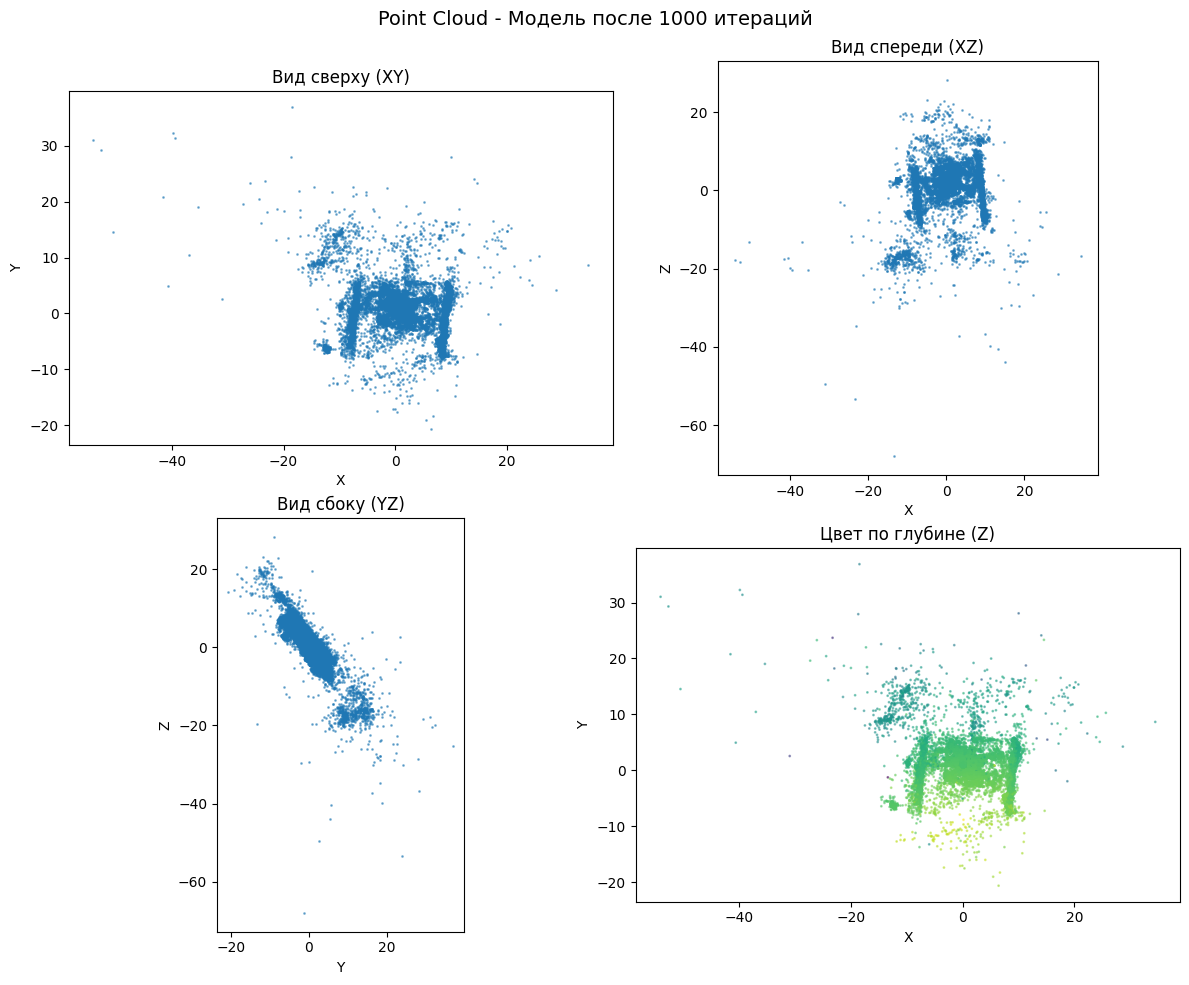

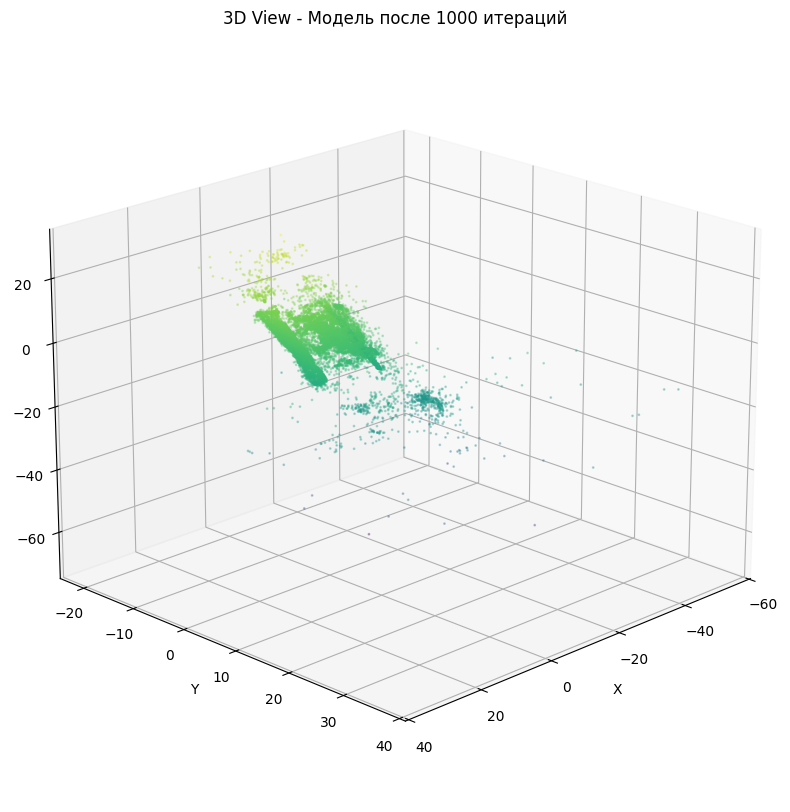


📊 Модель после 3000 итераций
----------------------------------------
✅ Загружено 433859 точек
  Количество точек: 433,859
  Диапазон X: [-43.41, 21.96]
  Диапазон Y: [-26.46, 43.20]
  Диапазон Z: [-62.12, 29.17]


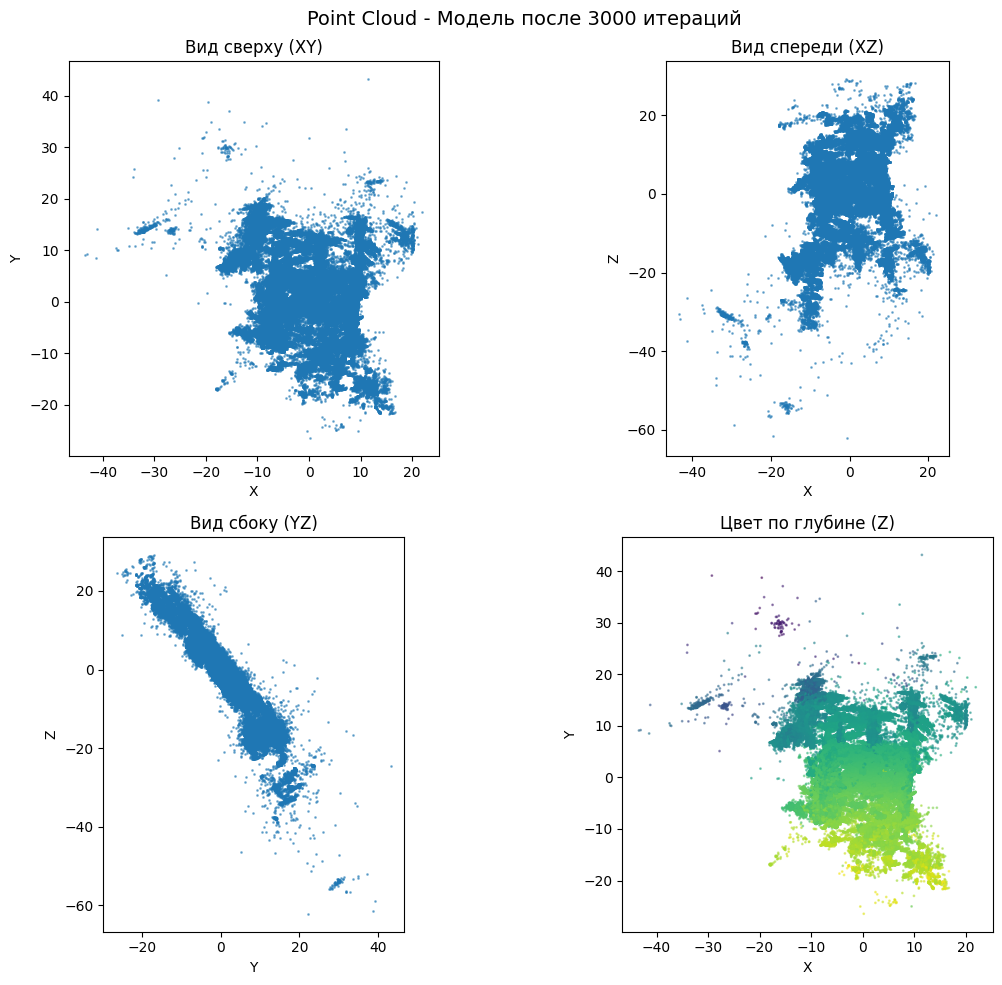

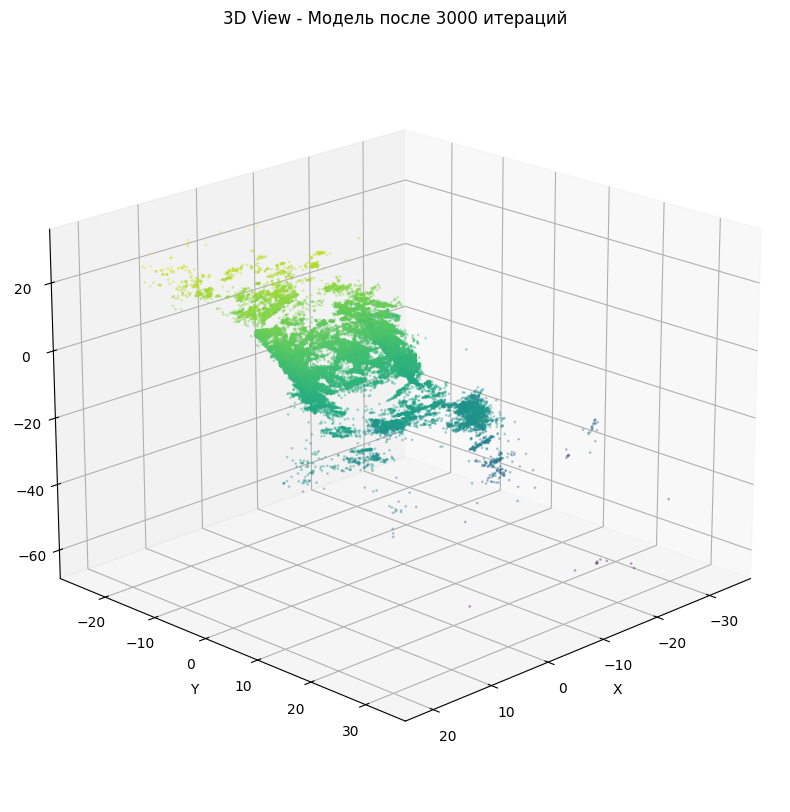

In [ ]:
def load_point_cloud(ply_path):
    """Загрузка point cloud из PLY файла"""
    if not os.path.exists(ply_path):
        print(f"Файл не найден: {ply_path}")
        return None

    try:
        ply = PlyData.read(ply_path)

        # Получаем координаты точек
        x = ply['vertex']['x']
        y = ply['vertex']['y']
        z = ply['vertex']['z']

        # Получаем цвета (если есть)
        if 'red' in ply['vertex'].data.dtype.names:
            colors = np.vstack([ply['vertex']['red'],
                                ply['vertex']['green'],
                                ply['vertex']['blue']]).T / 255.0
        else:
            colors = None

        points = np.vstack([x, y, z]).T

        print(f"✅ Загружено {len(points)} точек")
        return points, colors

    except Exception as e:
        print(f"❌ Ошибка загрузки: {e}")
        return None, None

def visualize_2d_projections(points, colors=None, title="Point Cloud Visualization"):
    """Визуализация point cloud в 2D проекциях"""
    if points is None or len(points) == 0:
        print("Нет данных для визуализации")
        return

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # XY проекция (вид сверху)
    ax = axes[0, 0]
    sc = ax.scatter(points[:, 0], points[:, 1], c=colors, s=1, alpha=0.5)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Вид сверху (XY)')
    ax.set_aspect('equal')

    # XZ проекция (вид спереди)
    ax = axes[0, 1]
    ax.scatter(points[:, 0], points[:, 2], c=colors, s=1, alpha=0.5)
    ax.set_xlabel('X')
    ax.set_ylabel('Z')
    ax.set_title('Вид спереди (XZ)')
    ax.set_aspect('equal')

    # YZ проекция (вид сбоку)
    ax = axes[1, 0]
    ax.scatter(points[:, 1], points[:, 2], c=colors, s=1, alpha=0.5)
    ax.set_xlabel('Y')
    ax.set_ylabel('Z')
    ax.set_title('Вид сбоку (YZ)')
    ax.set_aspect('equal')

    # 3D проекция (с использованием цветовой карты для глубины)
    ax = axes[1, 1]
    if colors is not None:
        sc = ax.scatter(points[:, 0], points[:, 1], c=points[:, 2], s=1, alpha=0.5, cmap='viridis')
        plt.colorbar(sc, ax=ax, label='Z координата')
    else:
        sc = ax.scatter(points[:, 0], points[:, 1], c=points[:, 2], s=1, alpha=0.5, cmap='viridis')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Цвет по глубине (Z)')
    ax.set_aspect('equal')

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

def visualize_3d_with_matplotlib(points, colors=None, title="3D Point Cloud"):
    """3D визуализация с matplotlib (интерактивная)"""
    if points is None or len(points) == 0:
        print("Нет данных для визуализации")
        return

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Уменьшаем количество точек для производительности
    sample_size = min(50000, len(points))
    indices = np.random.choice(len(points), sample_size, replace=False)
    points_sample = points[indices]

    if colors is not None:
        colors_sample = colors[indices]
        ax.scatter(points_sample[:, 0], points_sample[:, 1], points_sample[:, 2],
                  c=colors_sample, s=1, alpha=0.3)
    else:
        ax.scatter(points_sample[:, 0], points_sample[:, 1], points_sample[:, 2],
                  c=points_sample[:, 2], s=1, alpha=0.3, cmap='viridis')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)

    # Автоматический поворот для лучшего обзора
    ax.view_init(elev=20, azim=45)

    plt.show()

# Визуализация результатов
print("=" * 60)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ GAUSSIAN SPLATTING")
print("=" * 60)

# Исправленные названия моделей и пути
for model_name, path, iterations in [
    ("Модель после 1000 итераций", "/content/output_7k", 1000),      # было 7k итераций -> 1000 итераций
    ("Модель после 3000 итераций", "/content/output_30k", 3000)     # было 30k итераций -> 3000 итераций
]:
    print(f"\n📊 {model_name}")
    print("-" * 40)

    ply_path = f"{path}/point_cloud/iteration_{iterations}/point_cloud.ply"

    if os.path.exists(ply_path):
        points, colors = load_point_cloud(ply_path)

        if points is not None:
            print(f"  Количество точек: {len(points):,}")
            print(f"  Диапазон X: [{points[:, 0].min():.2f}, {points[:, 0].max():.2f}]")
            print(f"  Диапазон Y: [{points[:, 1].min():.2f}, {points[:, 1].max():.2f}]")
            print(f"  Диапазон Z: [{points[:, 2].min():.2f}, {points[:, 2].max():.2f}]")

            # Визуализация
            visualize_2d_projections(points, colors, f"Point Cloud - {model_name}")

            # 3D визуализация
            visualize_3d_with_matplotlib(points, colors, f"3D View - {model_name}")
    else:
        print(f"  ❌ Файл не найден: {ply_path}")

# Выводы

1. В связи с ограниченностью ресурсов лабораторная работа не была реализована в полном объёме;

2. Много времени заняла загрузка и обработка видео, но поработать с этим было интересно;

3. От качества датасета сильно зависит итоговый рендер объекта. Если будет плохое перекрытие, смазанные и обрезанные кадры, то не удастся восстановить исходный объект;

4. Если бы все получилось, можно было бы оценить, насколько 3DGS превосходит COLMAP.